# Modelagem

Nesse notebook iremos testar diversas abordagens de modelagem e iremos escolher a que performar melhor no nosso dataset.

## Importando as Bibliotecas

Primeiro, vamos importar nossas bibliotecas.

In [128]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

## Carregando o Dataset

Agora, vamos carregar o dataset.

In [113]:
df = pd.read_parquet("../data/processed/03_processed.parquet")

In [114]:
df = df.convert_dtypes()

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   tipo_imovel                       7919 non-null   string  
 1   preco                             7919 non-null   Int64   
 2   condominio                        4602 non-null   Int64   
 3   area_m2                           7919 non-null   Int64   
 4   quartos                           7918 non-null   Int64   
 5   banheiros                         7918 non-null   Int64   
 6   vagas                             7286 non-null   Int64   
 7   piscina                           7919 non-null   boolean 
 8   espaco_gourmet                    7919 non-null   boolean 
 9   academia                          7919 non-null   boolean 
 10  spa_massagem                      7919 non-null   boolean 
 11  espaco_lazer                      7919 non-null   boolean 
 12  are

In [116]:
df.head(10)

,tipo_imovel,preco,condominio,area_m2,quartos,banheiros,vagas,piscina,espaco_gourmet,academia,...,distancia_aeroporto_km,faixa_area,faixa_condominio,m2_por_banheiro,m2_por_quarto,banheiros_por_m2,quartos_por_m2,banheiro_por_quarto,quarto_por_vaga,cluster
0,apartamento,350000,720,60,2,2,1,True,True,True,...,16.213545,pequeno,medio,30.0,30.0,0.033333,0.033333,1.0,2.0,4
1,apartamento,511914,<NA>,37,1,1,1,True,True,True,...,7.250204,pequeno,NaN,37.0,37.0,0.027027,0.027027,1.0,1.0,1
2,apartamento,980000,1037,125,3,5,2,True,True,False,...,8.381749,medio,alto,25.0,41.666667,0.04,0.024,1.666667,1.5,1
3,apartamento,2799000,1200,244,3,4,4,True,True,True,...,8.824588,grande,alto,61.0,81.333333,0.016393,0.012295,1.333333,0.75,14
4,apartamento,370000,460,57,2,2,1,True,True,True,...,9.267687,pequeno,medio,28.5,28.5,0.035088,0.035088,1.0,2.0,11
5,apartamento,499000,<NA>,55,2,2,1,True,True,True,...,4.911235,pequeno,NaN,27.5,27.5,0.036364,0.036364,1.0,2.0,7
6,apartamento,195000,350,52,1,1,<NA>,True,True,True,...,9.094186,pequeno,baixo,52.0,52.0,0.019231,0.019231,1.0,<NA>,8
7,apartamento,1210314,<NA>,128,3,3,2,True,True,True,...,6.613218,medio,NaN,42.666667,42.666667,0.023438,0.023438,1.0,1.5,1
8,apartamento,860000,880,105,3,4,2,True,True,True,...,7.747091,medio,alto,26.25,35.0,0.038095,0.028571,1.333333,1.5,1
9,apartamento,400000,400,55,2,2,1,True,True,True,...,3.412207,pequeno,baixo,27.5,27.5,0.036364,0.036364,1.0,2.0,7


## Divisão Treino-Teste

Nessa etapa de modelagem faremos otimização de hiperparâmetros dos nossos modelos e para checarmos a qualidade final do modelo iremos testâ-lo em dados de teste. Para isso precisamos dividir os dados de treinamento e de teste.

In [117]:
from sklearn.model_selection import train_test_split

X = df.drop("preco", axis="columns")
y = df["preco"]

random_state = 1667

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=random_state,
)

## Regressão Linear (Baseline)

O primeiro modelo que iremos treinar será o nosso baseline, uma regressão linear múltipla. Vamos inicialmente escrever o código de otimização dos nossos modelos com validação cruzada de 5 folds e usando o `Optuna` para criar o study do nosso modelo.

In [118]:
import optuna

from sklearn.model_selection import (
    KFold,
    cross_val_score,
    cross_validate,
)

random_state = 1667

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state,
)

def get_study(
    get_pipeline,
    get_parameters,
    scoring="neg_root_mean_squared_error",
    pruner=optuna.pruners.NopPruner(),
    n_trials=100,
):
    def objective(trial):
        parameters = get_parameters(trial)
        pipeline = get_pipeline(parameters)

        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
        )

        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=random_state
        )
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=True,
    )

    return study

Agora, vamos criar uma função que reporta as métricas de desempenho dos nossos modelos.

In [119]:
def report_scores(get_pipeline, study):
    pipeline = get_pipeline(study.best_params)

    scoring = {
        "R2": "r2",
        "RMSE": "neg_root_mean_squared_error",
        "MAE": "neg_mean_absolute_error",
        "MedAE": "neg_median_absolute_error",
        "MAPE": "neg_mean_absolute_percentage_error",
    }

    scores = cross_validate(
        pipeline,
        X_test,
        y_test,
        cv=cv,
        scoring=scoring,
    )

    for score_name in scoring.keys():
        score_value = abs(scores[f"test_{score_name}"].mean())

        if score_name == "R2":
            print(f"{score_name}: {score_value:.2f}")
        elif score_name == "MAPE":
            print(f"{score_name}: {score_value:.2f}%")
        else:
            print(f"{score_name}: R$ {score_value:.2f}%")


E vamos criar também uma função para fazermos a análise dos erros/resíduos do nosso modelo nos dados de teste.

In [129]:
def _build_error_df(X_test, y_test, y_pred):
    """Cria o DataFrame com previsões, resíduos e métricas de erro."""

    error_df = X_test.copy()

    error_df["y_true"] = y_test
    error_df["y_pred"] = y_pred
    error_df["residual"] = error_df["y_true"] - error_df["y_pred"]
    error_df["abs_error"] = error_df["residual"].abs()
    error_df["sq_error"] = error_df["residual"] ** 2

    # Evita divisão por zero
    denominator = error_df["y_true"].replace(0, np.nan)

    error_df["relative_error"] = (
        error_df["residual"] / denominator
    )

    error_df["absolute_relative_error"] = (
        error_df["abs_error"] / denominator
    )

    return error_df


def _plot_residuals_vs_predictions(error_df):
    """Plota resíduos vs previsões."""

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.scatterplot(
        data=error_df,
        x="y_pred",
        y="residual",
        alpha=0.5,
        ax=ax,
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.5,
    )

    ax.set(
        xlabel="Predição",
        ylabel="Resíduo",
        title="Resíduos vs Predição",
    )

    sns.despine()
    plt.tight_layout()
    plt.show()


def _plot_residual_distribution(error_df):
    """Plota a distribuição dos resíduos."""

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        data=error_df,
        x="residual",
        bins=50,
        kde=True,
        ax=ax,
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.5,
    )

    ax.set(
        xlabel="Resíduo",
        ylabel="Frequência",
        title="Distribuição dos Resíduos",
    )

    sns.despine()
    plt.tight_layout()
    plt.show()


def _plot_features_vs_residuals(error_df, features):
    """Plota resíduos vs múltiplas features na mesma figura."""

    n_features = len(features)

    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12, 5 * n_rows),
    )

    # Garante que axes sempre seja iterável
    axes = np.atleast_1d(axes).flatten()

    for ax, feature in zip(axes, features):

        sns.scatterplot(
            data=error_df,
            x=feature,
            y="residual",
            alpha=0.4,
            ax=ax,
        )

        ax.axhline(
            0,
            linestyle="--",
            linewidth=1.5,
        )

        ax.set(
            xlabel=feature,
            ylabel="Resíduo",
            title=f"Resíduo vs {feature}",
        )

    # Remove axes vazios caso o número de features seja ímpar
    for ax in axes[n_features:]:
        ax.remove()

    fig.suptitle(
        "Resíduos vs Features",
        fontsize=16,
        y=1.02,
    )

    sns.despine()
    plt.tight_layout()
    plt.show()


def _plot_absolute_error_vs_predictions(error_df):
    """Plota erro absoluto vs previsão."""

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.scatterplot(
        data=error_df,
        x="y_pred",
        y="abs_error",
        alpha=0.5,
        ax=ax,
    )

    ax.set(
        xlabel="Predição",
        ylabel="|Erro|",
        title="Erro Absoluto vs Predição",
    )

    sns.despine()
    plt.tight_layout()
    plt.show()


def _print_error_statistics(error_df):
    """Exibe estatísticas dos erros relativos."""

    print("\n=== Erro Relativo Absoluto ===")

    print(
        error_df["absolute_relative_error"]
        .describe()
    )


def _print_worst_predictions(error_df, n=20):
    """Exibe os casos com maiores erros absolutos."""

    print(f"\n=== {n} Maiores Erros Absolutos ===")

    worst = (
        error_df
        .sort_values(
            "abs_error",
            ascending=False,
        )
        .head(n)
    )

    print(worst)


def _print_worst_predictions_summary(
    error_df,
    features,
    n=30,
):
    """Exibe um resumo dos casos com maiores erros."""

    columns = [
        "y_true",
        "y_pred",
        "residual",
        "abs_error",
        *features,
    ]

    columns = [
        column
        for column in columns
        if column in error_df.columns
    ]

    print(f"\n=== Resumo dos {n} Maiores Erros ===")

    worst = (
        error_df
        .sort_values(
            "abs_error",
            ascending=False,
        )
        .loc[:, columns]
        .head(n)
    )

    print(worst)


def get_residual_analysis(
    study,
    get_pipeline,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    features=None,
    n_worst=20,
):
    """
    Treina o melhor modelo do Optuna e executa análise
    de resíduos e erros no conjunto de teste.
    """

    if features is None:
        features = [
            "area_m2",
            "condominio",
            "quartos",
            "banheiros",
        ]

    # --------------------------------------------------
    # 1. Treinamento
    # --------------------------------------------------

    parameters = study.best_params
    pipeline = get_pipeline(parameters)

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    # --------------------------------------------------
    # 2. Construção do DataFrame de erros
    # --------------------------------------------------

    error_df = _build_error_df(
        X_test=X_test,
        y_test=y_test,
        y_pred=y_pred,
    )

    # --------------------------------------------------
    # 3. Visualizações
    # --------------------------------------------------

    _plot_residuals_vs_predictions(error_df)

    _plot_residual_distribution(error_df)

    _plot_features_vs_residuals(
        error_df,
        features,
    )

    _plot_absolute_error_vs_predictions(error_df)

    # --------------------------------------------------
    # 4. Estatísticas
    # --------------------------------------------------

    _print_error_statistics(error_df)

    # --------------------------------------------------
    # 5. Investigação dos piores casos
    # --------------------------------------------------

    _print_worst_predictions(
        error_df,
        n=n_worst,
    )

    _print_worst_predictions_summary(
        error_df,
        features=features,
        n=n_worst,
    )

    return error_df

Vamos também separar as features do nosso dataset pelos tipos numéricos.

In [121]:
discrete_columns = ["quartos", "banheiros", "vagas"]

continuous_columns = (X_train
    .drop(discrete_columns, axis="columns")
    .select_dtypes(include=["Int64", "Float64"])
    .columns
    .to_list()
)

ordinal_columns = (X_train
    .select_dtypes(include=["category"])
    .columns
    .to_list()
)

categorical_columns = (X_train
    .select_dtypes(include="string")
    .columns
    .to_list()
)

boolean_columns = (X_train
    .select_dtypes(include="boolean")
    .columns
    .to_list()
)

Agora, vamos montar o nosso pipeline para regressão linear.

In [122]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
)
from sklearn.pipeline import Pipeline

from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer

def get_linear_regression_pipeline(parameters):
    fold = parameters["fold"]

    imputer = SimpleImputer(strategy="median")
    imputer.set_output(transform="pandas")

    discrete_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ])

    continuous_pipeline = Pipeline(steps=[
        ("imputer", imputer),
        ("clip", Winsorizer(
            capping_method="quantiles",
            tail="right",
            fold=fold,
            missing_values="ignore",
            variables=["condominio", "area_m2"],
        )),
        ("normalizer", YeoJohnsonTransformer(
            variables=["condominio", "area_m2"]
        )),
        ("scaler", RobustScaler()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )),
    ])

    ordinal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder()),
    ])


    boolean_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("continuous", continuous_pipeline, continuous_columns),
            ("discrete", discrete_pipeline, discrete_columns),
            ("categorical", categorical_pipeline, categorical_columns),
            ("ordinal", ordinal_pipeline, ordinal_columns),
            ("boolean", boolean_pipeline, boolean_columns),
        ],
        remainder="drop",
    )

    regressor = LinearRegression()

    transformer = QuantileTransformer(
        output_distribution="normal",
        random_state=random_state,
    )

    model = TransformedTargetRegressor(
        regressor=regressor,
        transformer=transformer,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    return pipeline

def get_linear_regression_parameters(trial):
    return {
        "fold": trial.suggest_float("fold", 0.001, 0.1),
    }

In [123]:
study = get_study(
    get_pipeline=get_linear_regression_pipeline,
    get_parameters=get_linear_regression_parameters,
    n_trials=100
)

[I 2026-08-22 12:36:36,691] A new study created in memory with name: no-name-a30957ab-09e0-4813-b38c-e807b2b6a2f2
Best trial: 0. Best value: -1.00293e+06:   1%|          | 1/100 [00:01<02:56,  1.78s/it]

[I 2026-08-22 12:36:38,471] Trial 0 finished with value: -1002934.6011240886 and parameters: {'fold': 0.08957769985380352}. Best is trial 0 with value: -1002934.6011240886.


Best trial: 1. Best value: -913169:   2%|▏         | 2/100 [00:02<02:08,  1.32s/it]     

[I 2026-08-22 12:36:39,460] Trial 1 finished with value: -913169.2067907788 and parameters: {'fold': 0.010034517749159456}. Best is trial 1 with value: -913169.2067907788.


Best trial: 1. Best value: -913169:   3%|▎         | 3/100 [00:03<01:51,  1.14s/it]

...

[I 2026-08-22 12:38:38,630] Trial 97 finished with value: -907031.1351563104 and parameters: {'fold': 0.003922118386523359}. Best is trial 84 with value: -900755.1693389267.


Best trial: 84. Best value: -900755:  99%|█████████▉| 99/100 [02:02<00:00,  1.05it/s]

[I 2026-08-22 12:38:39,538] Trial 98 finished with value: -907482.2026024793 and parameters: {'fold': 0.006831121257538719}. Best is trial 84 with value: -900755.1693389267.


Best trial: 84. Best value: -900755: 100%|██████████| 100/100 [02:03<00:00,  1.24s/it]

[I 2026-08-22 12:38:40,412] Trial 99 finished with value: -903395.3572099817 and parameters: {'fold': 0.003439094342074956}. Best is trial 84 with value: -900755.1693389267.


In [130]:
report_scores(get_linear_regression_pipeline, study)

R2: 0.61
RMSE: R$ 916297.27%
MAE: R$ 387421.31%
MedAE: R$ 136280.30%
MAPE: 0.28%


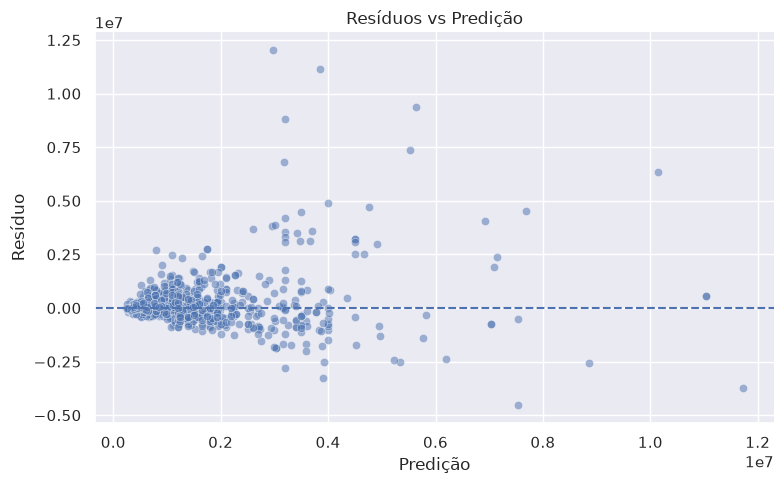

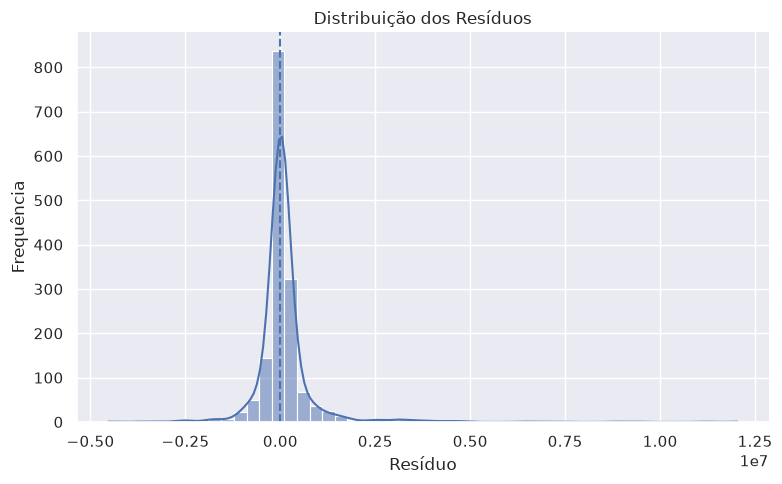

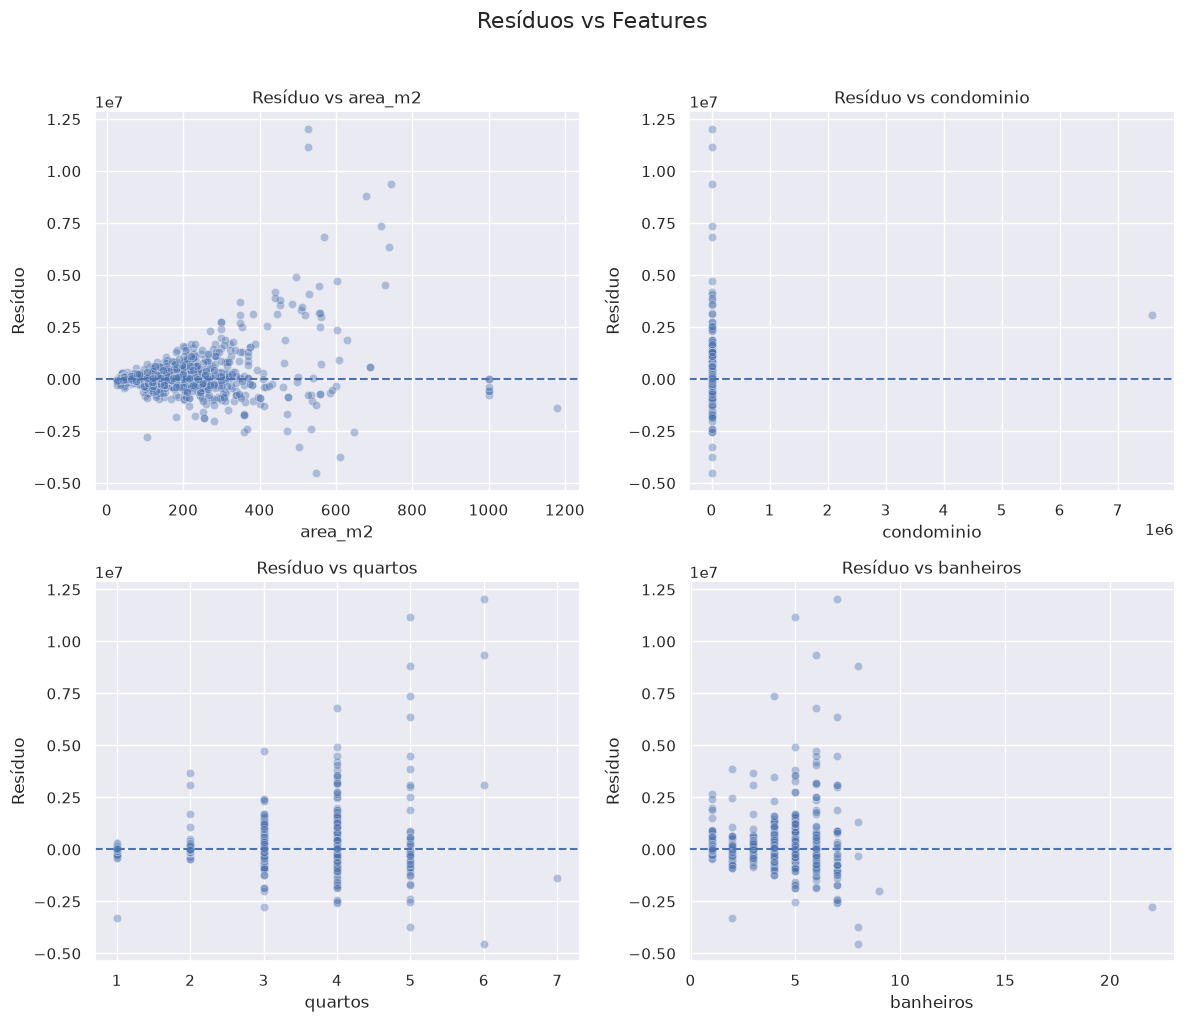

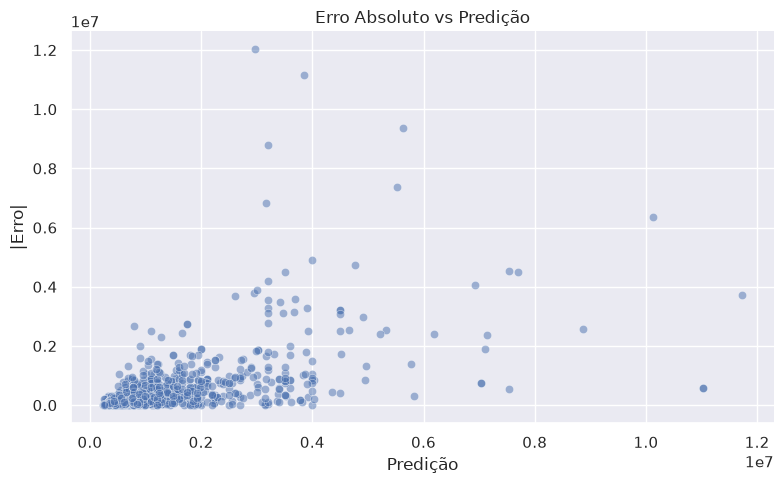


=== Erro Relativo Absoluto ===
count      1584.0
mean     0.277706
std      0.405982
min           0.0
25%      0.086957
50%      0.188641
75%      0.349152
max      6.804878
Name: absolute_relative_error, dtype: Float64

=== 20 Maiores Erros Absolutos ===
     tipo_imovel  condominio  area_m2  quartos  banheiros  vagas  piscina  \
5406   cobertura        1800      526        6          7      7    False   
5227   cobertura        4600      526        5          5      7     True   
5499   cobertura        4500      745        6          6      7     True   
4368        casa        <NA>      680        5          8   <NA>     True   
4301        casa        2500      718        5          4      6     True   
2051        casa        1840      568        4          6      3     True   
5353   cobertura        <NA>      740        5          7      6     True   
3863        casa        <NA>      495        4          5      6     True   
5297   cobertura        3000      604        3   

In [131]:
linear_regression_error_df = get_residual_analysis(study, get_linear_regression_pipeline)

## Regressão Linear com Regularização L1 (Lasso)

O primeiro modelo que iremos treinar é o modelo de Regressão Linear com Regularização L1, também conhecida como Lasso, sendo esse modelo o nosso baseline. Faremos a otimização de hiperparâmetros desse modelo usando a Validação Cruzada com 5 folds e usando a biblioteca `Optuna`.

In [186]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
)
from sklearn.model_selection import (
    KFold,
    cross_val_score,
    cross_validate,
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from feature_engine.outliers import Winsorizer

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state,
)

discrete_columns = ["quartos", "banheiros", "vagas"]
continuous_columns = (X_train
    .drop(discrete_columns, axis="columns")
    .select_dtypes(include=["int", "float"])
    .columns
    .to_list()
)

ordinal_columns = ["faixa_area", "faixa_condominio"]
categorical_columns = (X_train
    .drop(ordinal_columns, axis="columns")
    .select_dtypes(include="category")
    .columns
    .to_list()
)

def get_elastic_net_pipeline(parameters):
    continuous_pipeline = Pipeline(steps=[
        ("clip", Winsorizer(
            capping_method="quantiles",
            tail="right",
            fold=0.01,
            missing_values="ignore",
            variables=["condominio", "area_m2"],
        )),
        ("imputer", SimpleImputer(strategy="median")),
        # ("scaler", RobustScaler()),
    ])

    discrete_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(include_bias=False)),
        # ("scaler", RobustScaler()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )),
    ])

    ordinal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("continuous", continuous_pipeline, continuous_columns),
            # ("discrete", discrete_pipeline, discrete_columns),
            # ("categorical", categorical_pipeline, categorical_columns),
            # ("ordinal", ordinal_pipeline, ordinal_columns),
        ],
        remainder="drop",
    )

    regressor = Ridge(
        alpha=parameters["alpha"],
        # l1_ratio=parameters["l1_ratio"],
        max_iter=10000,
        random_state=random_state,
    )

    transformer = QuantileTransformer(
        output_distribution="normal"
    )

    model = TransformedTargetRegressor(
        regressor=regressor,
        transformer=transformer,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    return pipeline


def objective_elastic_net(trial):
    pipeline = get_elastic_net_pipeline({
        "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True),
        # "l1_ratio": trial.suggest_float("l1_ratio", 0.01, 0.99),
    })

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kfold,
        scoring="neg_mean_absolute_error",
    )

    return scores.mean()

Agora que montamos nossa função objetivo, vamos criar nosso estudo e executar a otimização de hiperparâmetros.

In [187]:
import optuna

study = optuna.create_study(
    direction="maximize",
)

study.optimize(
    objective_elastic_net,
    n_trials=10,
    show_progress_bar=True,
)

[I 2026-08-21 01:51:21,056] A new study created in memory with name: no-name-d9b09772-dd28-47e1-ac10-39433e79be61
Best trial: 0. Best value: -363592:  20%|██        | 2/10 [00:00<00:01,  5.43it/s]

[I 2026-08-21 01:51:21,250] Trial 0 finished with value: -363591.9479453561 and parameters: {'alpha': 0.046298921592357455}. Best is trial 0 with value: -363591.9479453561.
[I 2026-08-21 01:51:21,429] Trial 1 finished with value: -363631.63969894906 and parameters: {'alpha': 0.00012328962825281688}. Best is trial 0 with value: -363591.9479453561.


Best trial: 3. Best value: -363328:  40%|████      | 4/10 [00:00<00:01,  5.41it/s]

[I 2026-08-21 01:51:21,616] Trial 2 finished with value: -363521.2889108048 and parameters: {'alpha': 0.0008638243283103909}. Best is trial 2 with value: -363521.2889108048.
[I 2026-08-21 01:51:21,800] Trial 3 finished with value: -363328.17056343035 and parameters: {'alpha': 0.003115104529031915}. Best is trial 3 with value: -363328.17056343035.


Best trial: 3. Best value: -363328:  60%|██████    | 6/10 [00:01<00:00,  5.37it/s]

[I 2026-08-21 01:51:21,991] Trial 4 finished with value: -363597.12657647475 and parameters: {'alpha': 0.0003565131208486769}. Best is trial 3 with value: -363328.17056343035.
[I 2026-08-21 01:51:22,176] Trial 5 finished with value: -364260.232260515 and parameters: {'alpha': 0.11504524568065289}. Best is trial 3 with value: -363328.17056343035.


Best trial: 3. Best value: -363328:  80%|████████  | 8/10 [00:01<00:00,  5.44it/s]

[I 2026-08-21 01:51:22,363] Trial 6 finished with value: -363390.17428355676 and parameters: {'alpha': 0.0023775110645753374}. Best is trial 3 with value: -363328.17056343035.
[I 2026-08-21 01:51:22,541] Trial 7 finished with value: -366072.5369189773 and parameters: {'alpha': 0.7283009068546532}. Best is trial 3 with value: -363328.17056343035.


Best trial: 3. Best value: -363328: 100%|██████████| 10/10 [00:01<00:00,  5.47it/s]

[I 2026-08-21 01:51:22,714] Trial 8 finished with value: -364396.31376225414 and parameters: {'alpha': 0.13801928922038162}. Best is trial 3 with value: -363328.17056343035.
[I 2026-08-21 01:51:22,886] Trial 9 finished with value: -363578.8005120944 and parameters: {'alpha': 0.00047751835261808216}. Best is trial 3 with value: -363328.17056343035.


In [188]:
print(f"Best R^2: {study.best_value}")

Best R^2: -363328.17056343035


In [189]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
)

pipeline = get_elastic_net_pipeline(study.best_params)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("========== Lasso Metrics ==========")
print(f"R^2:  {r2_score(y_test, y_pred)}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")

========== Lasso Metrics ==========
R^2:  0.5381172369151144
MAE:  398549.04152190266
RMSE: 1060205.6761210298
MAPE: 0.29842961863326356


In [190]:
(y_test - y_pred).mean()

np.float64(120009.68628345832)

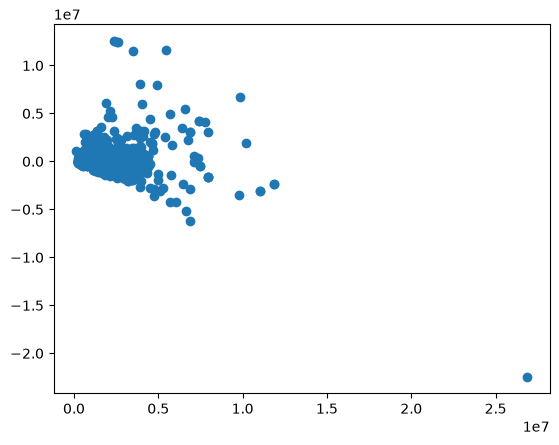

In [191]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=(y_test-y_pred))
plt.show()

In [200]:
opa = X_test.iloc[2100:2101].copy()
print(opa.to_string())

print(pipeline.predict(pd.DataFrame(opa)))

     tipo_imovel  condominio  area_m2  quartos  banheiros  vagas piscina espaco_gourmet academia spa_massagem espaco_lazer area_trabalho espaco_infantil area_esportiva portaria seguranca servicos_garagem acessibilidade   pets varanda area_verde espaco_natural acabamento_premium moveis_embutidos layout_premium cozinha servicos conforto_interno mobiliado casa_inteligente servicos_conectividade infra_energetica infra_hidrica servicos_sustentaveis   latitude  longitude  distancia_lago_das_rosas_km  distancia_vaca_brava_km  distancia_parque_areiao_km  distancia_parque_flamboyant_km  distancia_bosque_dos_buritis_km  distancia_flamboyant_shopping_km  distancia_goiania_shopping_km  distancia_passeio_das_aguas_km  distancia_shopping_cerrado_km  distancia_buriti_shopping_km  distancia_hospital_albert_einstein_km  distancia_hospital_mater_dei_km  distancia_hospital_anis_rassi_km  distancia_hospital_jacob_facuri_km  distancia_hugol_km  distancia_crer_km  distancia_hgg_km  distancia_ufg_samambaia_k

In [201]:
pipeline.named_steps["model"].regressor_.coef_

array([-4.11049014e-06,  5.15548781e-04,  5.15569217e+00,  3.54481081e+00,
        5.59937996e-01, -1.25155214e+00,  9.07060330e-02,  7.27857234e-02,
       -9.31013233e-01,  6.63068045e-02,  9.57229796e-01, -4.10754279e-02,
       -2.19944445e-02, -4.10143693e-02, -2.07398486e-01,  2.22191237e-01,
       -7.51628311e-01,  3.77257176e-02,  3.58527270e-03,  2.23129509e-01,
        4.32161788e-01,  1.76789672e-01,  1.27559185e+00, -8.69644027e-01,
       -1.16956934e+00,  1.12199350e+00,  1.02970352e+00, -6.74030173e-01,
       -2.46324135e-01, -2.05982045e-01,  1.52530748e-01, -6.50915925e-03,
        4.23888817e-03,  1.50819332e+01, -6.15510183e+00, -1.77184272e-01,
       -7.12130992e-02,  1.09113956e-01,  1.13867847e+00,  2.77188506e-02])

(array([ 40., 838., 625., 257., 231., 119.,  54.,  43.,   6.,  24.,  10.,
          8.,   7.,   9.,  12.,   9.,   5.,   6.,   4.,   0.,   2.,   0.,
          2.,   3.,   1.,   2.,   0.,   1.,   1.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         51.]),
 array([   49000.,   318510.,   588020.,   857530.,  1127040.,  1396550.,
         1666060.,  1935570.,  2205080.,  2474590.,  2744100.,  3013610.,
         3283120.,  3552630.,  3822140.,  4091650.,  4361160.,  4630670.,
         4900180.,  5169690.,  5439200.,  5708710.,  5978220.,  6247730.,
         6517240.,  67

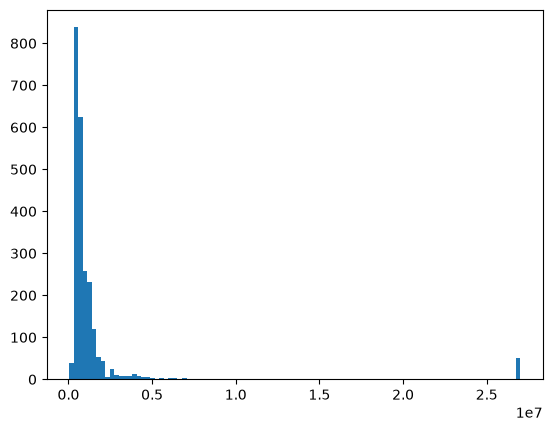

In [153]:
plt.hist(y_pred, bins=100)

(array([ 20., 241., 419., 417., 272., 150., 119., 113., 100.,  60.,  70.,
         50.,  40.,  16.,  25.,  13.,  28.,  12.,  16.,  18.,  25.,   9.,
         18.,   8.,  11.,  16.,   9.,   6.,   3.,   8.,   3.,   4.,   7.,
          1.,   1.,   0.,   5.,   0.,   1.,   1.,   1.,   3.,   1.,   5.,
          1.,   0.,   3.,   1.,   0.,   3.,   1.,   1.,   4.,   1.,   0.,
          0.,   0.,   0.,   0.,   3.,   0.,   0.,   0.,   0.,   0.,   2.,
          2.,   0.,   0.,   1.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,
          1.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          2.]),
 array([   68000.,   217320.,   366640.,   515960.,   665280.,   814600.,
          963920.,  1113240.,  1262560.,  1411880.,  1561200.,  1710520.,
         1859840.,  2009160.,  2158480.,  2307800.,  2457120.,  2606440.,
         2755760.,  2905080.,  3054400.,  3203720.,  3353040.,  3502360.,
         3651680.,  38

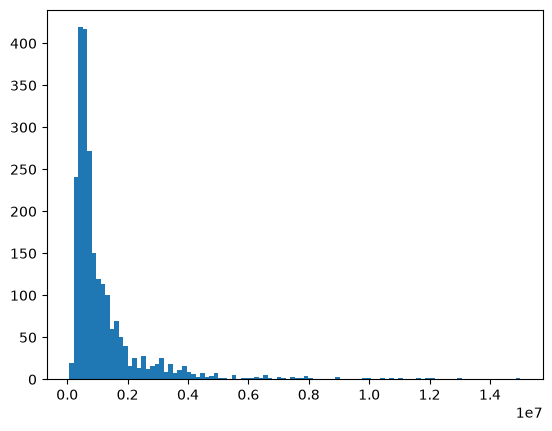

In [154]:
plt.hist(y_test, bins=100)

In [156]:
pipeline.named_steps["model"].regressor_.coef_

array([-7.86024037e-06,  3.55167813e-05,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -0.00000000e+00, -0.00000000e+00,  1.69102087e-02,
       -0.00000000e+00, -0.00000000e+00, -7.32930454e-03,  0.00000000e+00,
        0.00000000e+00,  5.75855596e-03, -3.67916842e-02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.27686416e-03,  0.00000000e+00,
        0.00000000e+00, -1.67709478e-03,  0.00000000e+00,  0.00000000e+00,
        1.46584429e-03,  6.19717516e-05, -0.00000000e+00, -0.00000000e+00,
       -2.11507631e-03, -0.00000000e+00,  1.63218657e-02,  7.52965398e-05,
       -2.09730224e-04, -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
       -3.17222488e-02,  0.00000000e+00,  1.31998426e-01,  2.38033046e-03,
        0.00000000e+00,  1.06876741e-01,  0.00000000e+00, -0.00000000e+00,
       -2.27186934e-03,  9.83234174e-03, -4.60010985e-03, -9.76592028e-04,
       -8.86404534e-04, -1.90852937e-02, -0.00000000e+00,  0.00000000e+00,
       -0.00000000e+00, -

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("preco", axis="columns")
y = df["preco"]

random_state = 1667

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=random_state,
)

In [24]:
from sklearn.model_selection import (
    KFold,
    cross_val_score,
)
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from feature_engine.outliers import Winsorizer

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state,
)

ordinal_columns = ["faixa_area", "faixa_condominio"]
numeric_columns = (X_train
    .select_dtypes(include="number")
    .columns
    .to_list()
)
categorical_columns = (X_train
    .drop(ordinal_columns, axis="columns")
    .select_dtypes(include="category")
    .columns
    .to_list()
)

def get_xgboost_pipeline(parameters):
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )),
    ])

    ordinal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_columns),
            # ("discrete", discrete_pipeline, discrete_columns),
            # ("categorical", categorical_pipeline, categorical_columns),
            # ("ordinal", ordinal_pipeline, ordinal_columns),
        ],
        remainder="drop",
    )

    model = XGBRegressor(
        n_estimators=parameters["n_estimators"],
        learning_rate=parameters["learning_rate"],
        max_depth=parameters["max_depth"],
        min_child_weight=parameters["min_child_weight"],
        subsample=parameters["subsample"],
        colsample_bytree=parameters["colsample_bytree"],
        reg_alpha=parameters["reg_alpha"],
        reg_lambda=parameters["reg_lambda"],
        #gamma=parameters["gamma"],
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=random_state,
        n_jobs=-1,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline

def objective_xgboost(trial):
    parameters = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            300,
            2000,
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True,
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            2,
            10,
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            20,
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0,
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0,
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10.0,
            log=True,
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-3,
            100.0,
            log=True,
        ),
    }

    pipeline = get_xgboost_pipeline(parameters)

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kfold,
        scoring="neg_mean_absolute_error",
        n_jobs=1,
    )

    return scores.mean()

In [25]:
import optuna

study = optuna.create_study(
    direction="maximize",
)

study.optimize(
    objective_xgboost,
    n_trials=10,
    show_progress_bar=True,
)

[I 2026-08-21 02:43:07,832] A new study created in memory with name: no-name-6f004bc8-5faa-4c33-b3cf-f2e33a7c650d
Best trial: 0. Best value: -223771:  10%|█         | 1/10 [00:08<01:14,  8.25s/it]

[I 2026-08-21 02:43:16,078] Trial 0 finished with value: -223770.834375 and parameters: {'n_estimators': 384, 'learning_rate': 0.09860684831825844, 'max_depth': 10, 'min_child_weight': 4, 'subsample': 0.8329353336246427, 'colsample_bytree': 0.5580003264025204, 'reg_alpha': 5.127890201294006, 'reg_lambda': 0.023195097708241512}. Best is trial 0 with value: -223770.834375.


Best trial: 0. Best value: -223771:  20%|██        | 2/10 [00:15<01:03,  7.93s/it]

[I 2026-08-21 02:43:23,774] Trial 1 finished with value: -236389.340625 and parameters: {'n_estimators': 774, 'learning_rate': 0.19940895246557266, 'max_depth': 9, 'min_child_weight': 17, 'subsample': 0.8510233345051794, 'colsample_bytree': 0.7469003392685457, 'reg_alpha': 0.0319740850147225, 'reg_lambda': 0.001307210217319033}. Best is trial 0 with value: -223770.834375.


Best trial: 0. Best value: -223771:  30%|███       | 3/10 [00:34<01:30, 12.93s/it]

...

[I 2026-08-21 02:44:45,476] Trial 7 finished with value: -233063.46875 and parameters: {'n_estimators': 1651, 'learning_rate': 0.02925544635433711, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8929395538667375, 'colsample_bytree': 0.8287691940592226, 'reg_alpha': 1.0532645219296107e-07, 'reg_lambda': 8.271809182964194}. Best is trial 4 with value: -218434.575.


Best trial: 4. Best value: -218435:  90%|█████████ | 9/10 [01:39<00:08,  8.20s/it]

[I 2026-08-21 02:44:47,276] Trial 8 finished with value: -285672.14375 and parameters: {'n_estimators': 452, 'learning_rate': 0.023486037039904227, 'max_depth': 4, 'min_child_weight': 16, 'subsample': 0.7218974911047743, 'colsample_bytree': 0.6238763690195654, 'reg_alpha': 1.0992875003715206e-05, 'reg_lambda': 0.006253716527502511}. Best is trial 4 with value: -218434.575.


Best trial: 4. Best value: -218435: 100%|██████████| 10/10 [01:50<00:00, 11.04s/it]

[I 2026-08-21 02:44:58,180] Trial 9 finished with value: -226656.41875 and parameters: {'n_estimators': 1605, 'learning_rate': 0.15665332994245532, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 0.9763230268967431, 'colsample_bytree': 0.6639389251280875, 'reg_alpha': 0.00029740438480004553, 'reg_lambda': 2.0171421580506776}. Best is trial 4 with value: -218434.575.


In [26]:
print(f"Best R^2: {study.best_value}")

Best R^2: -218434.575


In [27]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
)

pipeline = get_xgboost_pipeline(study.best_params)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("========== Lasso Metrics ==========")
print(f"R^2:  {r2_score(y_test, y_pred)}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")

========== Lasso Metrics ==========
R^2:  0.882175624370575
MAE:  201135.0625
RMSE: 535478.25
MAPE: 0.1802596151828766


In [28]:
y.mean()

np.float64(1197591.9421644148)

In [22]:
(y_test - y_pred).mean()

np.float64(-17877.81746501473)

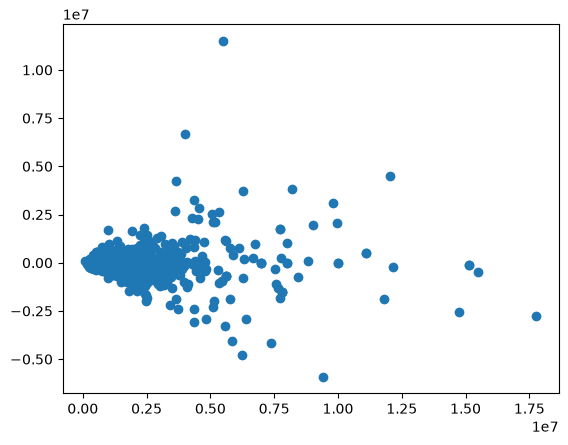

In [23]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=(y_test-y_pred))
plt.show()